# KIN module comparison across IC3392, NGC4383, and NGC4419

This notebook compares only the stellar kinematics (`KIN`) maps from the old `v3_v7.2.1` run and the new `v3tk_v7.6.8` run for the three galaxies.

It is the cross-galaxy version of the KIN sections in the per-galaxy notebooks:

- `20260315_check_IC3392_v3tk_runs.ipynb`
- `20260427_check_NGC4383_v3tk_runs.ipynb`
- `20260427_check_NGC4419_v3tk_runs.ipynb`

Each map figure uses galaxies as rows, so the same KIN quantity can be checked across all three galaxies in one place.

Interpretation caveat: the old/new differences should not be read as pure `nGIST` version effects. Three ingredients changed at once:

1. the input cubes changed from the previous `v3` reduction to the newer `v3tk` reduction; this is expected to be a minor contribution,
2. the CONFIG changed substantially, especially the KIN fitting range from `4800-7000` to `4800-9100`, which is likely a major driver,
3. the `nGIST` version changed from v7.2.1 to v7.6.8, including KIN fitting changes in dust handling, template selection, noise treatment, and clipping.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import TwoSlopeNorm

plt.style.use('seaborn-v0_8-whitegrid')

root = Path('.')
GALAXIES = ['IC3392', 'NGC4383', 'NGC4419']
KIN_QUANTITIES = ['V', 'SIGMA', 'H3', 'H4']
CENTERED_QUANTITIES = {'V', 'H3', 'H4'}
TECHNICAL_NOTE = root / '..' / 'MAUVE' / '20260430_ngist_v721_v768_comparison.md'

files = {
    galaxy: {
        'old': root / 'v3_v7.2.1' / galaxy / f'{galaxy}_KIN_maps.fits',
        'new': root / 'v3tk_v7.6.8' / galaxy / f'{galaxy}_kin_maps.fits',
    }
    for galaxy in GALAXIES
}

config_files = {
    galaxy: {
        'old': root / 'v3_v7.2.1' / galaxy / 'CONFIG',
        'new': root / 'v3tk_v7.6.8' / galaxy / 'CONFIG',
    }
    for galaxy in GALAXIES
}

file_rows = []
for galaxy, run_files in files.items():
    for run, path in run_files.items():
        if not path.exists():
            raise FileNotFoundError(f'Missing {galaxy} {run} KIN file: {path}')
        if not config_files[galaxy][run].exists():
            raise FileNotFoundError(f'Missing {galaxy} {run} CONFIG file: {config_files[galaxy][run]}')
        file_rows.append({
            'galaxy': galaxy,
            'run': run,
            'kin_path': str(path),
            'config_path': str(config_files[galaxy][run]),
        })

if not TECHNICAL_NOTE.exists():
    print(f'Warning: technical note not found: {TECHNICAL_NOTE}')

print('All KIN and CONFIG files found.')
display(pd.DataFrame(file_rows))


All KIN and CONFIG files found.


,galaxy,run,kin_path,config_path
0,IC3392,old,v3_v7.2.1/IC3392/IC3392_KIN_maps.fits,v3_v7.2.1/IC3392/CONFIG
1,IC3392,new,v3tk_v7.6.8/IC3392/IC3392_kin_maps.fits,v3tk_v7.6.8/IC3392/CONFIG
2,NGC4383,old,v3_v7.2.1/NGC4383/NGC4383_KIN_maps.fits,v3_v7.2.1/NGC4383/CONFIG
3,NGC4383,new,v3tk_v7.6.8/NGC4383/NGC4383_kin_maps.fits,v3tk_v7.6.8/NGC4383/CONFIG
4,NGC4419,old,v3_v7.2.1/NGC4419/NGC4419_KIN_maps.fits,v3_v7.2.1/NGC4419/CONFIG
5,NGC4419,new,v3tk_v7.6.8/NGC4419/NGC4419_kin_maps.fits,v3tk_v7.6.8/NGC4419/CONFIG


## CONFIG and technical context

Before looking at maps, check the run configuration. The main old/new KIN changes are the much wider fitting range in the new run, updated masks/templates/LSF labels, different velocity scale and initial sigma, and new v7.6.8 options for dust/noise/template handling.

The technical note at `../MAUVE/20260430_ngist_v721_v768_comparison.md` summarizes the expected `nGIST` v7.2.1 to v7.6.8 behaviour. The key KIN expectation is: `V` is usually the most robust, `SIGMA` is more sensitive, and `H3`/`H4` can change noticeably.


In [2]:
def parse_simple_config(path):
    config = {}
    section = None
    with open(path) as fh:
        for raw_line in fh:
            line = raw_line.rstrip()
            if not line or line.lstrip().startswith('#'):
                continue
            if not line.startswith(' ') and line.endswith(':'):
                section = line[:-1]
                config[section] = {}
                continue
            if section is not None and ':' in line:
                key, value = line.strip().split(':', 1)
                config[section][key.strip()] = value.strip()
    return config


CONFIG_FIELDS = [
    ('GENERAL', 'INPUT'),
    ('GENERAL', 'LSF_DATA'),
    ('READ_DATA', 'ORIGIN'),
    ('READ_DATA', 'LMIN_TOT'),
    ('READ_DATA', 'LMAX_TOT'),
    ('PREPARE_SPECTRA', 'VELSCALE'),
    ('KIN', 'SPEC_MASK'),
    ('KIN', 'LMIN'),
    ('KIN', 'LMAX'),
    ('KIN', 'SIGMA'),
    ('KIN', 'BIAS'),
    ('KIN', 'ADEG'),
    ('KIN', 'MDEG'),
    ('KIN', 'LSF_TEMP'),
    ('KIN', 'LIBRARY'),
    ('KIN', 'DOCLEAN'),
    ('KIN', 'OPT_TEMP'),
    ('KIN', 'DUST_CORR'),
    ('KIN', 'NOISE'),
]

config_rows = []
for galaxy in GALAXIES:
    for run in ('old', 'new'):
        config = parse_simple_config(config_files[galaxy][run])
        row = {'galaxy': galaxy, 'run': run}
        for section, key in CONFIG_FIELDS:
            row[f'{section}.{key}'] = config.get(section, {}).get(key, '')
        config_rows.append(row)

config_summary = pd.DataFrame(config_rows)
display(config_summary)

kin_config_delta_rows = []
for galaxy in GALAXIES:
    old = config_summary[(config_summary['galaxy'] == galaxy) & (config_summary['run'] == 'old')].iloc[0]
    new = config_summary[(config_summary['galaxy'] == galaxy) & (config_summary['run'] == 'new')].iloc[0]
    for column in config_summary.columns:
        if column in {'galaxy', 'run'}:
            continue
        if str(old[column]) != str(new[column]):
            kin_config_delta_rows.append(
                {
                    'galaxy': galaxy,
                    'field': column,
                    'old': old[column],
                    'new': new[column],
                }
            )

kin_config_deltas = pd.DataFrame(kin_config_delta_rows)
display(kin_config_deltas)


,galaxy,run,GENERAL.INPUT,GENERAL.LSF_DATA,READ_DATA.ORIGIN,READ_DATA.LMIN_TOT,READ_DATA.LMAX_TOT,PREPARE_SPECTRA.VELSCALE,KIN.SPEC_MASK,KIN.LMIN,...,KIN.SIGMA,KIN.BIAS,KIN.ADEG,KIN.MDEG,KIN.LSF_TEMP,KIN.LIBRARY,KIN.DOCLEAN,KIN.OPT_TEMP,KIN.DUST_CORR,KIN.NOISE
0,IC3392,old,/arc/projects/mauve/cubes/v3.0/IC3392_DATACUBE...,lsf_MUSE-WFM,"218,218",4800,7000,53,specMask_KIN,4800,...,66,Auto,12,0,lsf_MILES,MILES_EMLINES/,true,,,
1,IC3392,new,/scratch/pawsey1308/mauve/cubes/v3tk/IC3392_DA...,lsf_MUSE-WFM-MILES,"219,219",4800,9100,41,specMask_KIN_narrow10,4800,...,82,muse_snr_prefit,23,0,lsf_MILES,EMILES_baseFe_EMLINES/,true,default,true,variance
2,NGC4383,old,/arc/projects/mauve/cubes/v3.0/NGC4383_DATACUB...,lsf_MUSE-WFM,"317,353",4800,7000,53,specMask_KIN,4800,...,63,Auto,12,0,lsf_MILES,MILES_EMLINES/,true,,,
3,NGC4383,new,/scratch/pawsey1308/mauve/cubes/v3tk/NGC4383_D...,lsf_MUSE-WFM-MILES,"317,353",4800,9100,41,specMask_KIN_narrow10,4800,...,63,muse_snr_prefit,23,0,lsf_MILES,EMILES_baseFe_EMLINES/,true,default,true,variance
4,NGC4419,old,/arc/projects/mauve/cubes/v3.0/NGC4419_DATACUB...,lsf_MUSE-WFM,"314,321",4800,7000,53,specMask_KIN,4800,...,95,Auto,12,0,lsf_MILES,MILES_EMLINES/,true,,,
5,NGC4419,new,/scratch/pawsey1308/mauve/cubes/v3tk/NGC4419_D...,lsf_MUSE-WFM-MILES,"315,322",4800,9100,41,specMask_KIN_narrow10,4800,...,107,muse_snr_prefit,23,0,lsf_MILES,EMILES_baseFe_EMLINES/,true,default,true,variance


,galaxy,field,old,new
0,IC3392,GENERAL.INPUT,/arc/projects/mauve/cubes/v3.0/IC3392_DATACUBE...,/scratch/pawsey1308/mauve/cubes/v3tk/IC3392_DA...
1,IC3392,GENERAL.LSF_DATA,lsf_MUSE-WFM,lsf_MUSE-WFM-MILES
2,IC3392,READ_DATA.ORIGIN,"218,218","219,219"
3,IC3392,READ_DATA.LMAX_TOT,7000,9100
4,IC3392,PREPARE_SPECTRA.VELSCALE,53,41
5,IC3392,KIN.SPEC_MASK,specMask_KIN,specMask_KIN_narrow10
6,IC3392,KIN.LMAX,7000,9100
7,IC3392,KIN.SIGMA,66,82
8,IC3392,KIN.BIAS,Auto,muse_snr_prefit
9,IC3392,KIN.ADEG,12,23


## Reading the KIN results

Use the visual map grids and scatter plots as the primary diagnostic, especially for `V` and `SIGMA`.

- `H3` and `H4` are already expected to change because higher moments are sensitive to residual structure, masking, clipping, and template mixture. They are shown for completeness but are not treated as stability tests.
- `SIGMA` needs careful inspection. Clear deviations are expected because velocity dispersion is sensitive to template mismatch, continuum treatment, dust/noise handling, and the much wider fitted wavelength range.
- `V` can look broadly good because it follows the 1:1 relation, but an offset from the line still matters. The focused V/SIGMA diagnostics below therefore show `new - old` residuals as well as old-vs-new scatter.

Causal interpretation should stay conservative: map differences combine minor cube-reduction changes, major CONFIG changes, and `nGIST` version changes.


## KIN FITS structure

This cell lists the HDUs for the old and new KIN files. The comparison cells below use the common stellar kinematic maps `V`, `SIGMA`, `H3`, and `H4`.


In [3]:
def hdu_shape_from_header(hdu):
    naxis = int(hdu.header.get('NAXIS', 0) or 0)
    if naxis == 0:
        return None
    return tuple(hdu.header.get(f'NAXIS{i}', '?') for i in range(naxis, 0, -1))


def summarize_hdus(path):
    rows = []
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        for idx, hdu in enumerate(hdul):
            shape = hdu_shape_from_header(hdu)
            dtype = None
            data_error = None
            try:
                data = hdu.data
                if data is not None:
                    shape = tuple(data.shape)
                    dtype = str(data.dtype)
            except Exception as exc:
                data_error = f'{type(exc).__name__}: {exc}'
                bitpix = hdu.header.get('BITPIX')
                dtype = f'BITPIX={bitpix}' if bitpix is not None else 'unreadable'

            rows.append(
                {
                    'idx': idx,
                    'extname': hdu.name,
                    'type': type(hdu).__name__,
                    'shape': shape,
                    'dtype': dtype,
                    'data_error': data_error,
                }
            )
    return pd.DataFrame(rows)


hdu_summary_rows = []
for galaxy in GALAXIES:
    for run in ('old', 'new'):
        summary = summarize_hdus(files[galaxy][run])
        summary.insert(0, 'run', run)
        summary.insert(0, 'galaxy', galaxy)
        hdu_summary_rows.append(summary)

hdu_summary = pd.concat(hdu_summary_rows, ignore_index=True)
display(hdu_summary)


,galaxy,run,idx,extname,type,shape,dtype,data_error
0,IC3392,old,0,PRIMARY,PrimaryHDU,None,None,None
1,IC3392,old,1,V,ImageHDU,"(438, 437)",>f8,None
2,IC3392,old,2,SIGMA,ImageHDU,"(438, 437)",>f8,None
3,IC3392,old,3,H3,ImageHDU,"(438, 437)",>f8,None
4,IC3392,old,4,H4,ImageHDU,"(438, 437)",>f8,None
...,...,...,...,...,...,...,...,...
61,NGC4419,new,7,FORM_ERR_H3,ImageHDU,"(643, 629)",>f8,None
62,NGC4419,new,8,FORM_ERR_H4,ImageHDU,"(643, 629)",>f8,None
63,NGC4419,new,9,SNR_POSTFIT,ImageHDU,"(643, 629)",>f8,None
64,NGC4419,new,10,RED_CHI2,ImageHDU,"(643, 629)",>f8,None


## Load maps and comparison helpers

The helper functions mirror the existing per-galaxy notebooks, but the data structure is keyed by galaxy first and KIN quantity second.


In [4]:
def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


def align_map_pair(old_map, new_map, label=None):
    if old_map.shape == new_map.shape:
        return old_map, new_map
    if old_map.ndim != new_map.ndim:
        raise ValueError(
            f'{label or "map"}: cannot align maps with different dimensions: '
            f'old {old_map.shape}, new {new_map.shape}'
        )

    common_shape = tuple(min(old_n, new_n) for old_n, new_n in zip(old_map.shape, new_map.shape))
    old_slices = tuple(slice(0, n) for n in common_shape)
    new_slices = tuple(slice(0, n) for n in common_shape)
    if label is not None:
        print(
            f'Warning: {label} shape mismatch old {old_map.shape}, new {new_map.shape}; '
            f'using common crop {common_shape}.'
        )
    return old_map[old_slices], new_map[new_slices]


def read_map_pair(old_path, new_path, extname, label=None):
    old_map = read_map(old_path, extname)
    new_map = read_map(new_path, extname)
    return align_map_pair(old_map, new_map, label or extname)


def percent_change_map(old_map, new_map):
    old_map, new_map = align_map_pair(old_map, new_map)
    pct = np.full(old_map.shape, np.nan, dtype=float)
    mask = np.isfinite(old_map) & np.isfinite(new_map) & (old_map != 0)
    pct[mask] = 100.0 * (new_map[mask] - old_map[mask]) / np.abs(old_map[mask])
    return pct, mask


def finite_values(arrays):
    chunks = []
    for arr in arrays:
        vals = np.asarray(arr)[np.isfinite(arr)]
        if vals.size > 0:
            chunks.append(vals.ravel())
    if len(chunks) == 0:
        return np.array([], dtype=float)
    return np.concatenate(chunks)


def compare_stats(old_map, new_map, label, galaxy):
    old_map, new_map = align_map_pair(old_map, new_map, f'{galaxy} {label}')
    mask = np.isfinite(old_map) & np.isfinite(new_map)
    pct_map, pct_mask = percent_change_map(old_map, new_map)

    if mask.sum() == 0:
        return {
            'galaxy': galaxy,
            'quantity': label,
            'n_valid': 0,
            'n_valid_nonzero_old': 0,
            'median_old': np.nan,
            'median_new': np.nan,
            'median_delta_new_minus_old': np.nan,
            'mean_delta_new_minus_old': np.nan,
            'std_delta': np.nan,
            'rms_delta': np.nan,
            'median_pct_change': np.nan,
            'median_abs_pct_change': np.nan,
            'mean_pct_change': np.nan,
            'std_pct_change': np.nan,
            'rms_pct_change': np.nan,
            'pearson_r': np.nan,
        }

    old_vals = old_map[mask]
    new_vals = new_map[mask]
    delta = new_vals - old_vals

    if old_vals.size > 1 and np.nanstd(old_vals) > 0 and np.nanstd(new_vals) > 0:
        pearson_r = float(np.corrcoef(old_vals, new_vals)[0, 1])
    else:
        pearson_r = np.nan

    pct_vals = pct_map[pct_mask]
    if pct_vals.size == 0:
        median_pct = np.nan
        median_abs_pct = np.nan
        mean_pct = np.nan
        std_pct = np.nan
        rms_pct = np.nan
    else:
        median_pct = float(np.nanmedian(pct_vals))
        median_abs_pct = float(np.nanmedian(np.abs(pct_vals)))
        mean_pct = float(np.nanmean(pct_vals))
        std_pct = float(np.nanstd(pct_vals))
        rms_pct = float(np.sqrt(np.nanmean(pct_vals**2)))

    return {
        'galaxy': galaxy,
        'quantity': label,
        'n_valid': int(mask.sum()),
        'n_valid_nonzero_old': int(pct_mask.sum()),
        'median_old': float(np.nanmedian(old_vals)),
        'median_new': float(np.nanmedian(new_vals)),
        'median_delta_new_minus_old': float(np.nanmedian(delta)),
        'mean_delta_new_minus_old': float(np.nanmean(delta)),
        'std_delta': float(np.nanstd(delta)),
        'rms_delta': float(np.sqrt(np.nanmean(delta**2))),
        'median_pct_change': median_pct,
        'median_abs_pct_change': median_abs_pct,
        'mean_pct_change': mean_pct,
        'std_pct_change': std_pct,
        'rms_pct_change': rms_pct,
        'pearson_r': pearson_r,
    }


def robust_limits(arr, p=(2, 98)):
    vals = np.asarray(arr)[np.isfinite(arr)]
    if vals.size == 0:
        return 0.0, 1.0
    lo, hi = np.nanpercentile(vals, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(vals), np.nanmax(vals)
        if lo == hi:
            hi = lo + 1.0
    return float(lo), float(hi)


def robust_symmetric_limit(arr, percentile=98, fallback=1.0):
    vals = np.abs(np.asarray(arr)[np.isfinite(arr)])
    if vals.size == 0:
        return float(fallback)
    limit = np.nanpercentile(vals, percentile)
    if not np.isfinite(limit) or limit == 0:
        limit = np.nanmax(vals)
    if not np.isfinite(limit) or limit == 0:
        limit = fallback
    return float(limit)


maps = {
    galaxy: {
        quantity: read_map_pair(
            files[galaxy]['old'],
            files[galaxy]['new'],
            quantity,
            f'{galaxy} KIN_{quantity}',
        )
        for quantity in KIN_QUANTITIES
    }
    for galaxy in GALAXIES
}

print('Loaded KIN maps:')
for galaxy in GALAXIES:
    print(f'  {galaxy}: {list(maps[galaxy].keys())}')


Loaded KIN maps:
  IC3392: ['V', 'SIGMA', 'H3', 'H4']
  NGC4383: ['V', 'SIGMA', 'H3', 'H4']
  NGC4419: ['V', 'SIGMA', 'H3', 'H4']


## Map comparison grids

Each figure compares one KIN quantity. Rows are galaxies. Columns are old run, new run, and difference. For `V` and `SIGMA`, the last column is percent difference. For `H3` and `H4`, percent difference is skipped because the values cross zero and percent changes become unstable.


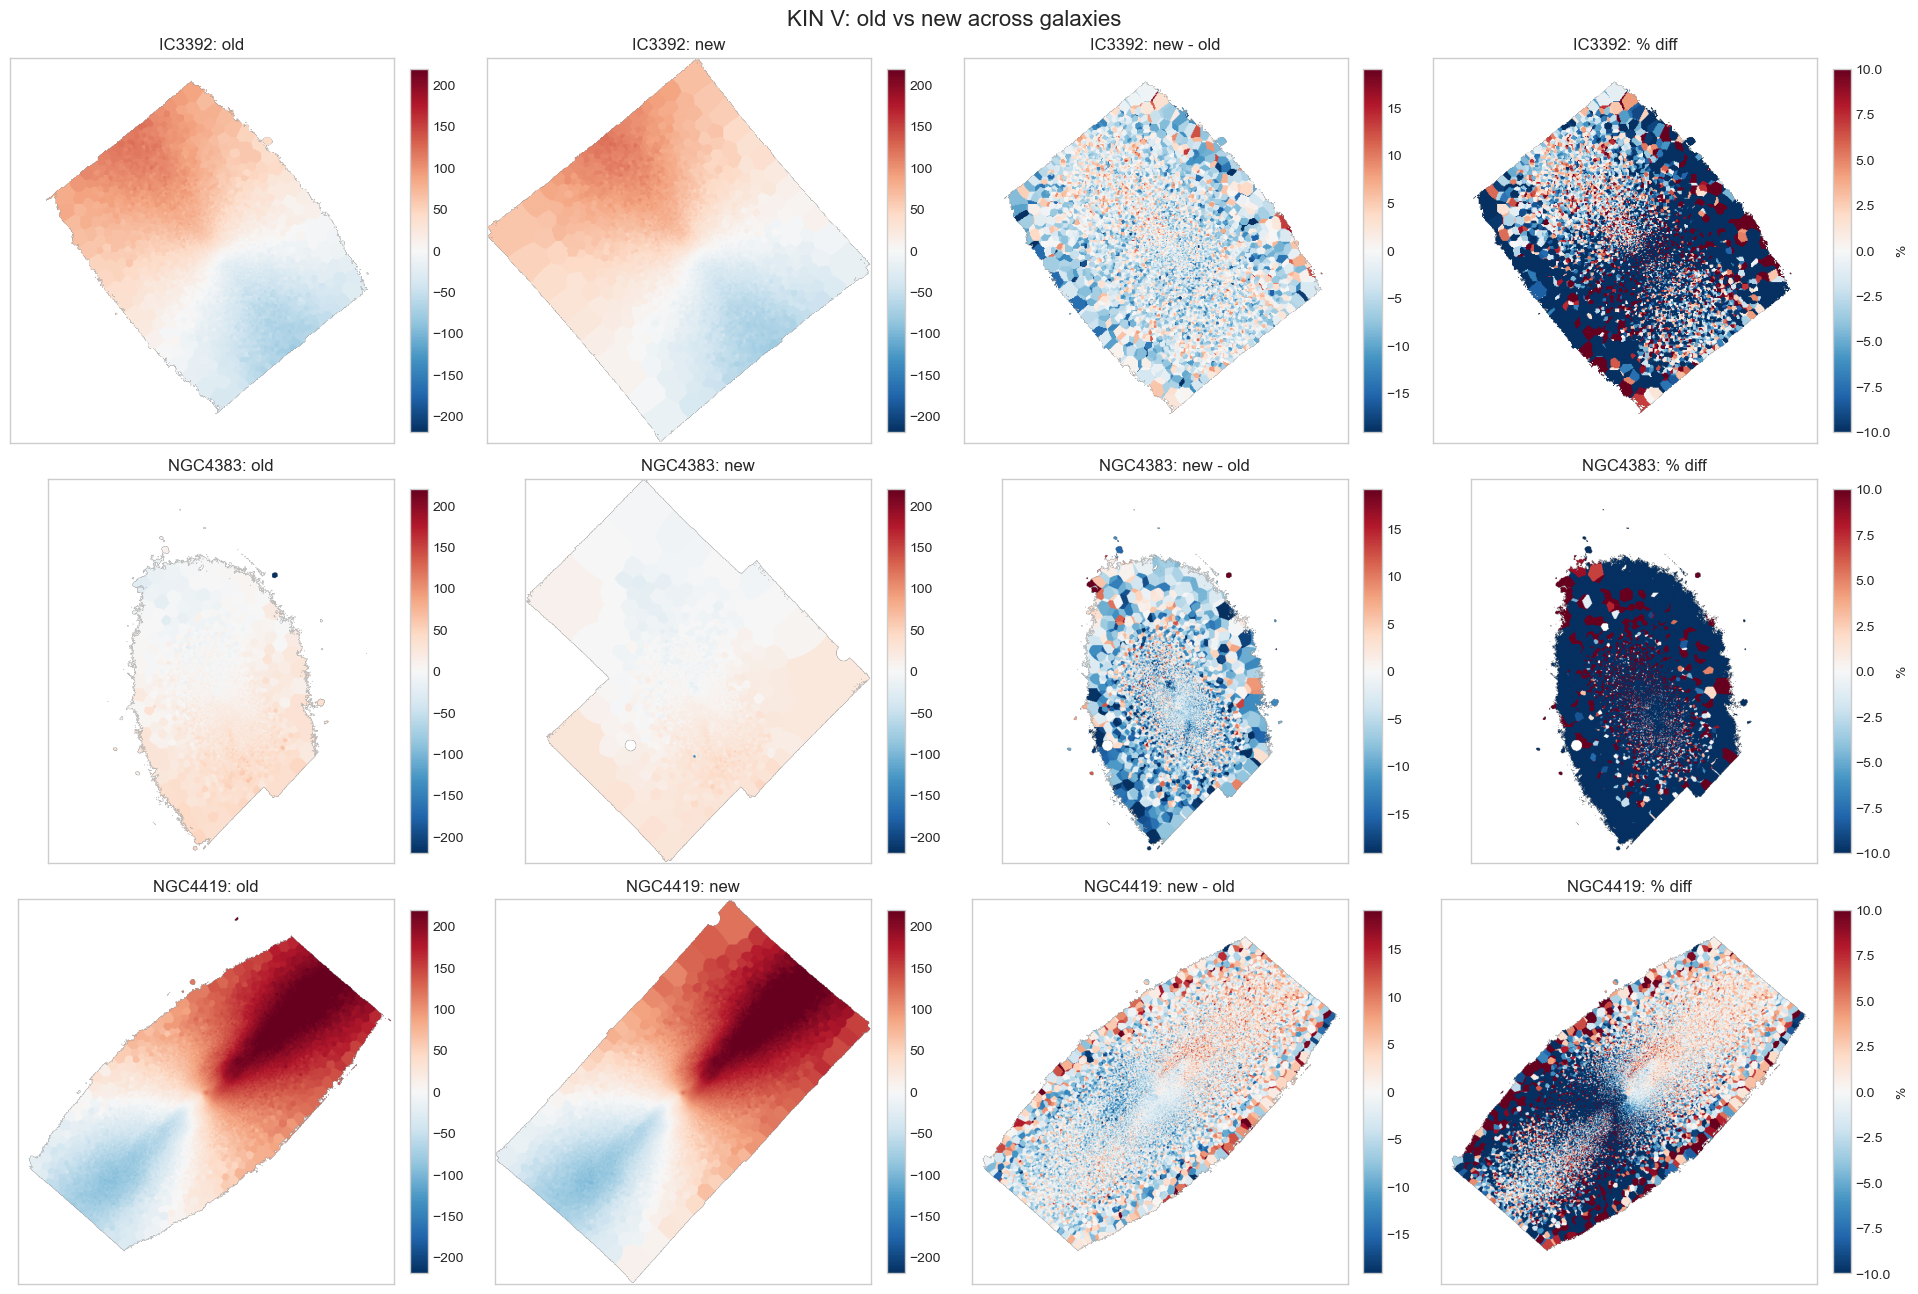

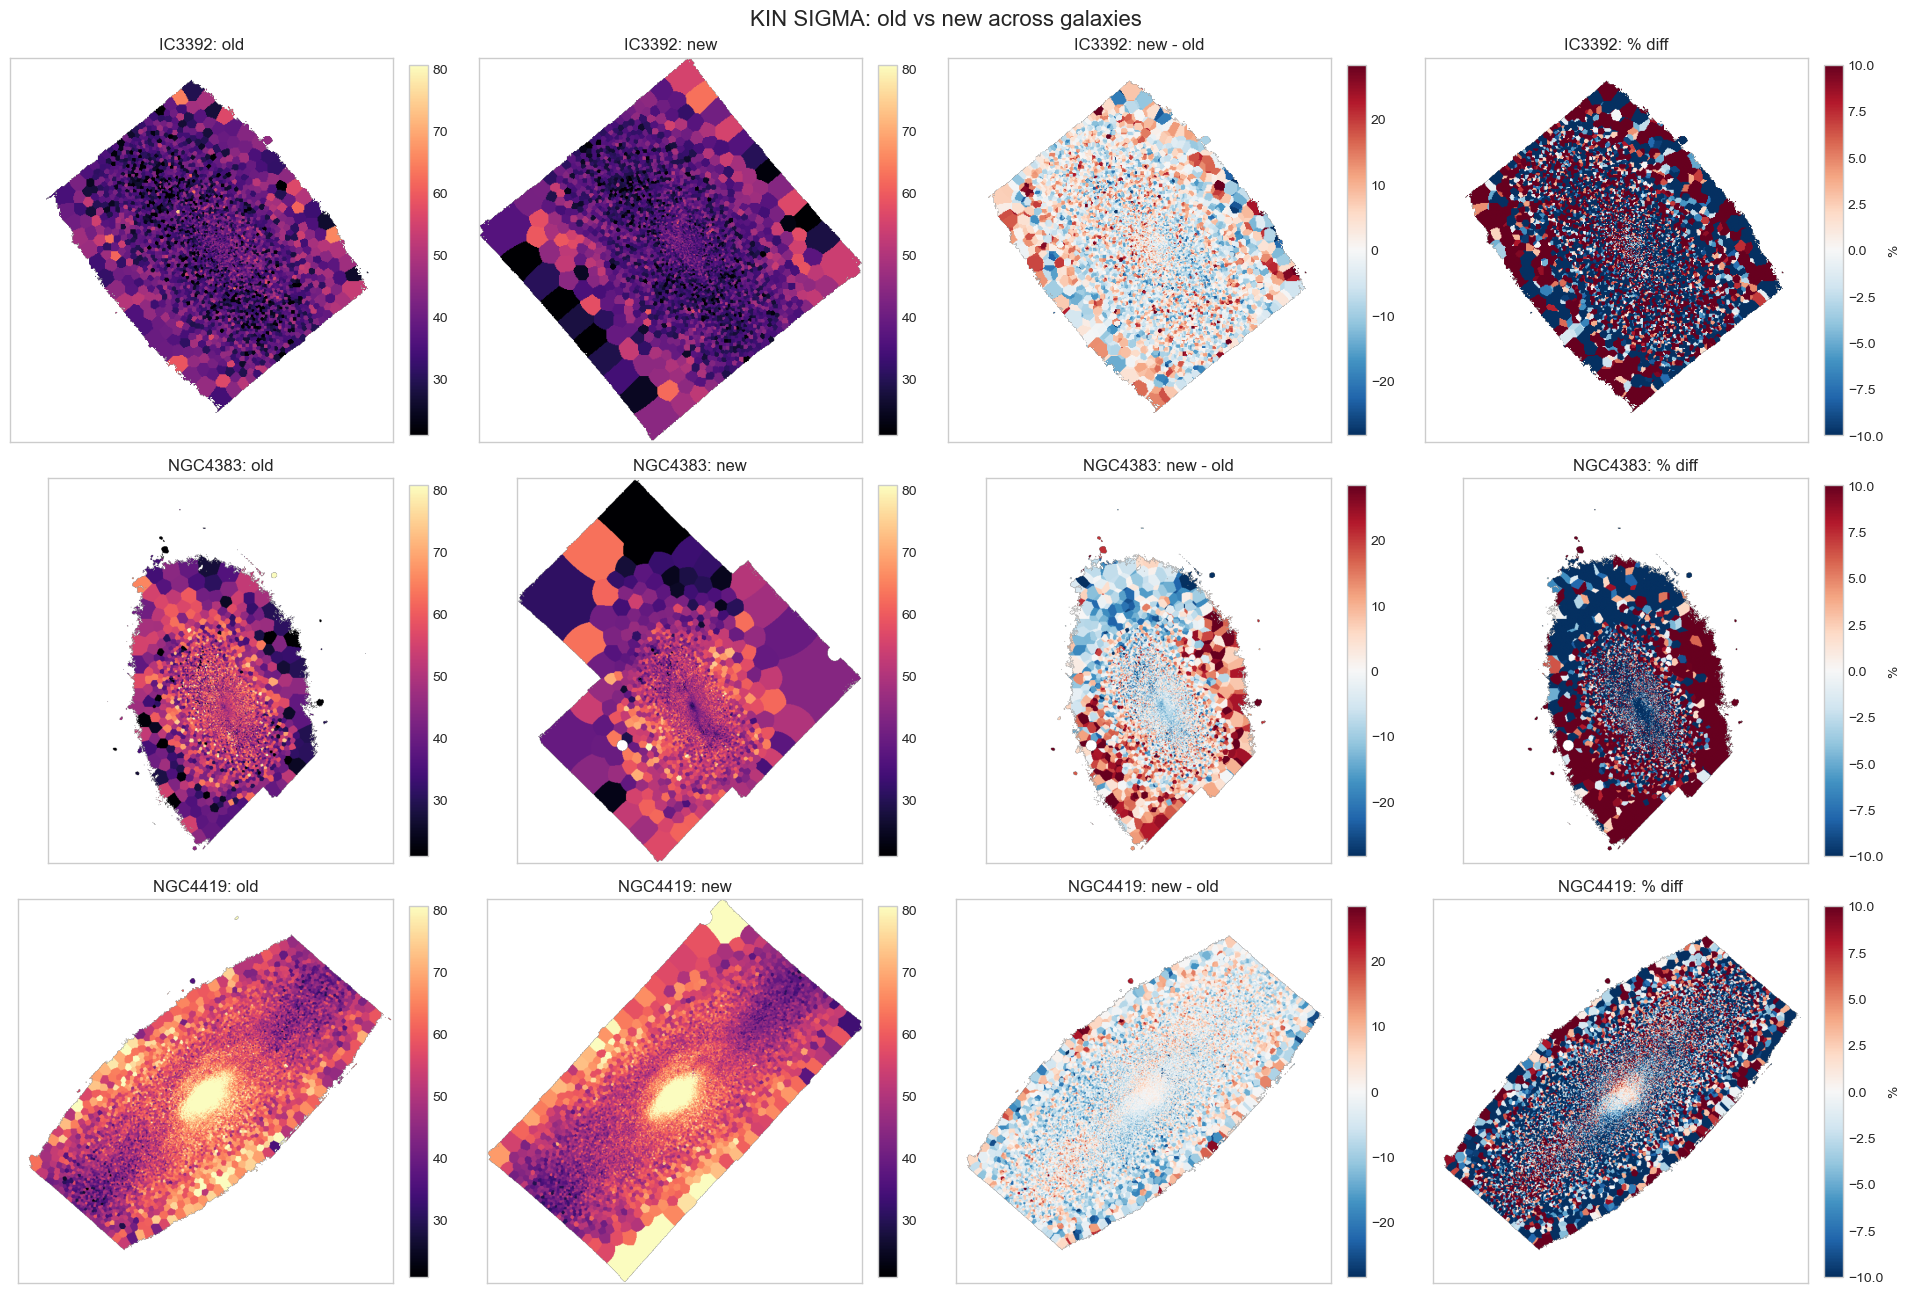

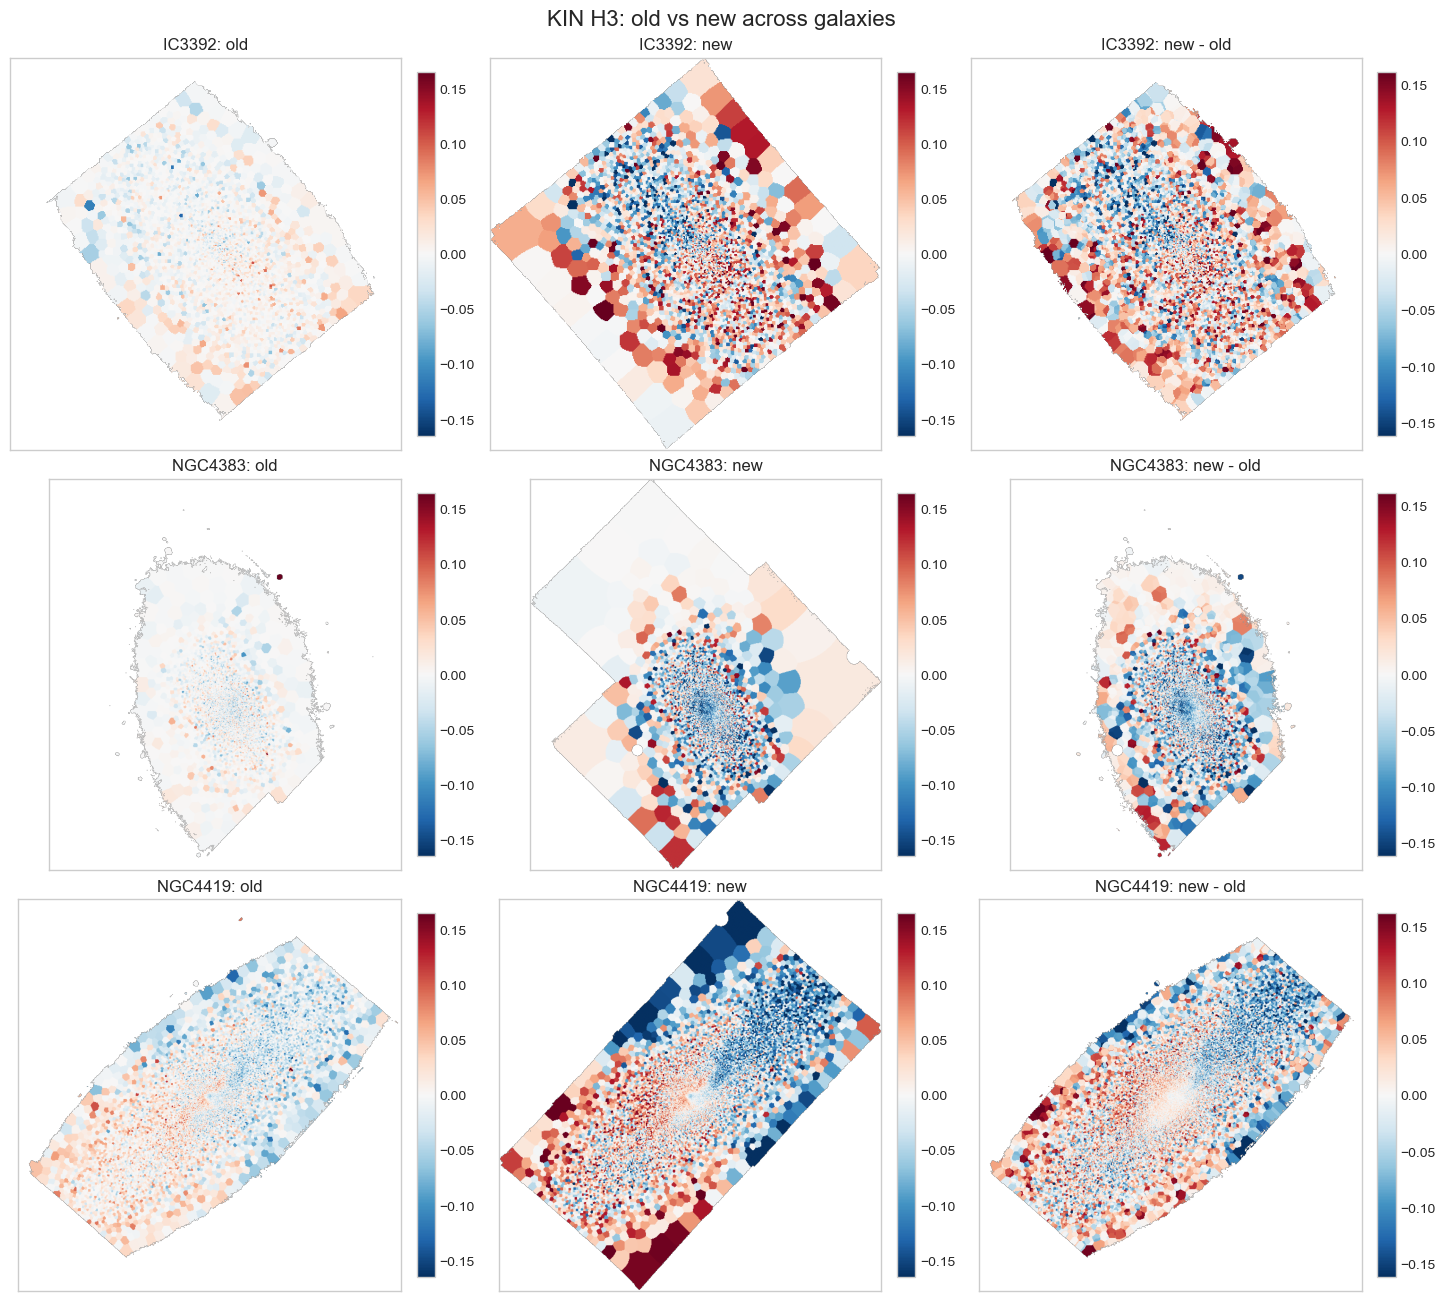

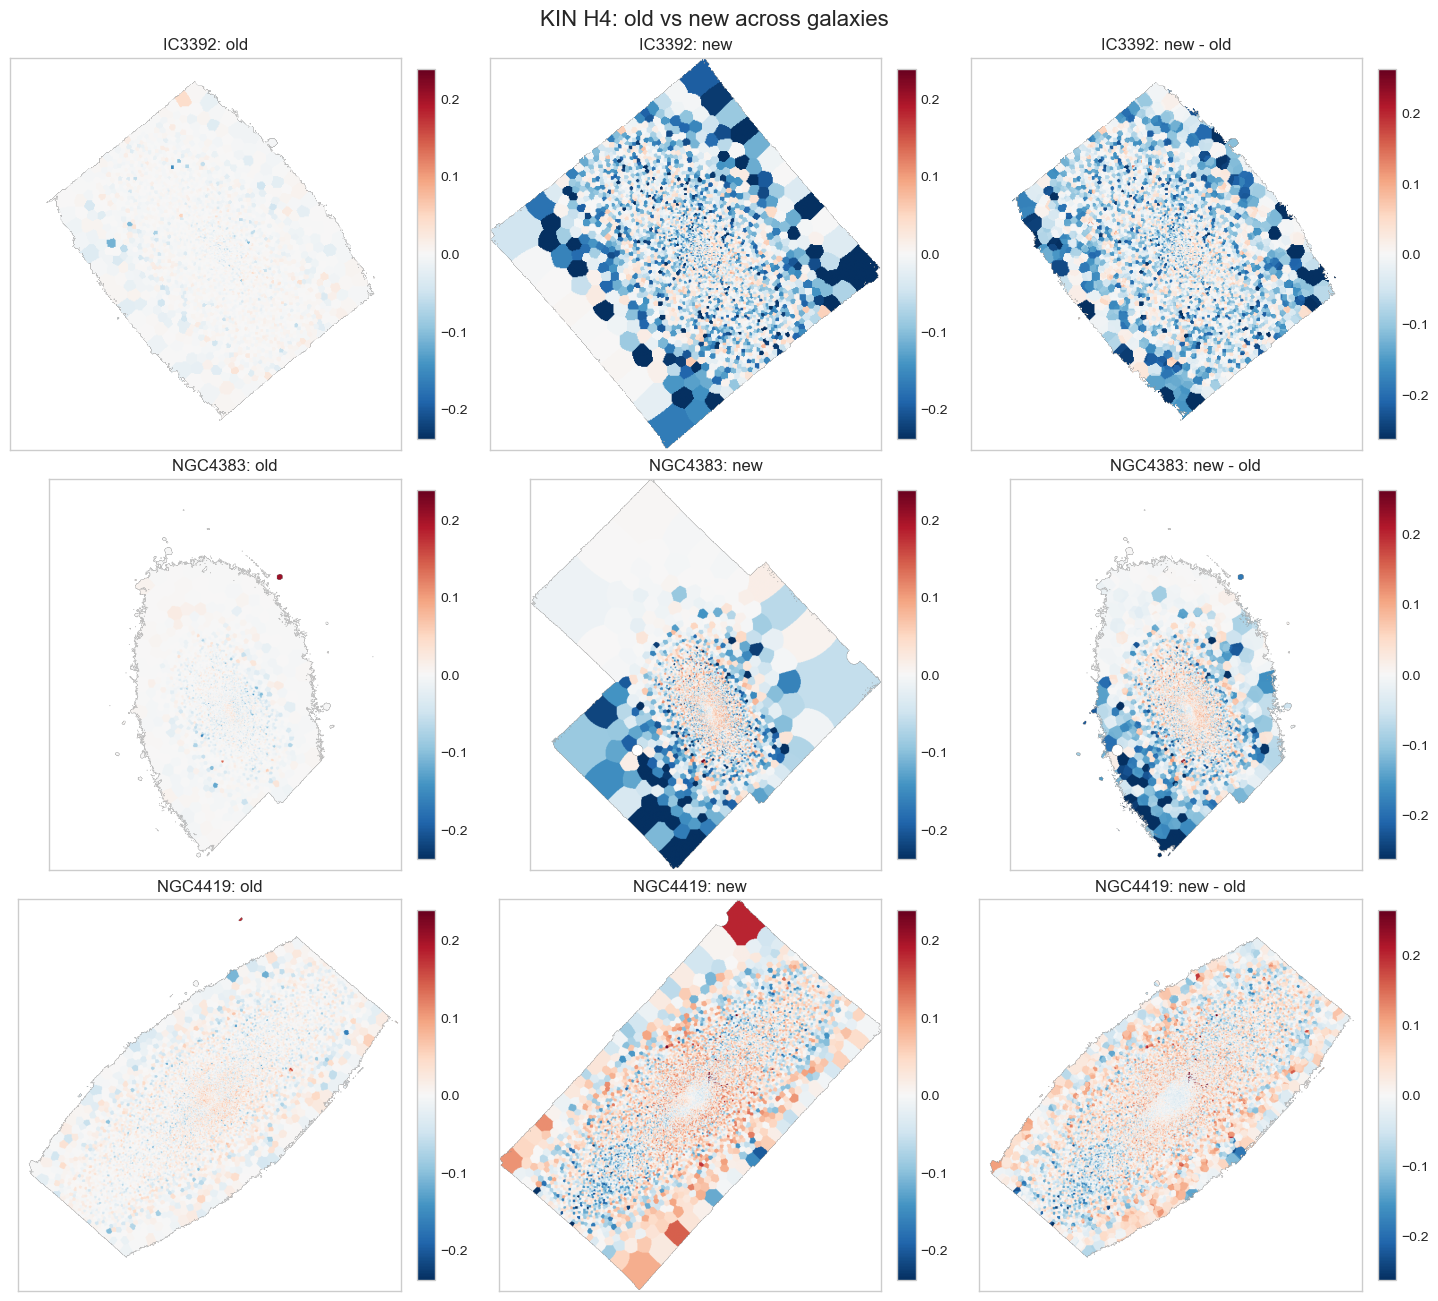

In [5]:
KIN_CMAP = {
    'V': 'RdBu_r',
    'SIGMA': 'magma',
    'H3': 'RdBu_r',
    'H4': 'RdBu_r',
}


def plot_kin_grid(quantity, show_percent=None, percent_limit=10.0):
    if show_percent is None:
        show_percent = quantity in {'V', 'SIGMA'}

    old_maps = [maps[galaxy][quantity][0] for galaxy in GALAXIES]
    new_maps = [maps[galaxy][quantity][1] for galaxy in GALAXIES]
    diff_maps = [new - old for old, new in zip(old_maps, new_maps)]
    pct_maps = [percent_change_map(old, new)[0] for old, new in zip(old_maps, new_maps)]

    main_values = finite_values(old_maps + new_maps)
    diff_values = finite_values(diff_maps)

    cmap_main = KIN_CMAP.get(quantity, 'viridis')
    main_kwargs = {'origin': 'lower', 'cmap': cmap_main}
    if quantity in CENTERED_QUANTITIES:
        main_limit = robust_symmetric_limit(main_values, percentile=98, fallback=1.0)
        main_kwargs['norm'] = TwoSlopeNorm(vmin=-main_limit, vcenter=0.0, vmax=main_limit)
    else:
        vmin, vmax = robust_limits(main_values)
        main_kwargs['vmin'] = vmin
        main_kwargs['vmax'] = vmax

    diff_limit = robust_symmetric_limit(diff_values, percentile=98, fallback=1.0)
    diff_norm = TwoSlopeNorm(vmin=-diff_limit, vcenter=0.0, vmax=diff_limit)

    ncols = 4 if show_percent else 3
    fig, axes = plt.subplots(
        len(GALAXIES),
        ncols,
        figsize=(4.8 * ncols, 4.3 * len(GALAXIES)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(f'KIN {quantity}: old vs new across galaxies', fontsize=16)

    for row, galaxy in enumerate(GALAXIES):
        old_map, new_map = maps[galaxy][quantity]
        diff = new_map - old_map

        panels = [
            ('old', old_map, main_kwargs),
            ('new', new_map, main_kwargs),
            ('new - old', diff, {'origin': 'lower', 'cmap': 'RdBu_r', 'norm': diff_norm}),
        ]
        if show_percent:
            pct = pct_maps[row]
            pct_norm = TwoSlopeNorm(vmin=-percent_limit, vcenter=0.0, vmax=percent_limit)
            panels.append(
                (
                    '% diff',
                    pct,
                    {'origin': 'lower', 'cmap': 'RdBu_r', 'norm': pct_norm},
                )
            )

        for col, (panel_title, panel_map, imshow_kwargs) in enumerate(panels):
            ax = axes[row, col]
            im = ax.imshow(panel_map, **imshow_kwargs)
            ax.set_title(f'{galaxy}: {panel_title}')
            ax.set_xticks([])
            ax.set_yticks([])
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            if panel_title == '% diff':
                cbar.set_label('%')

    plt.show()


for quantity in KIN_QUANTITIES:
    plot_kin_grid(quantity)


## Visual inspection: old vs new scatter plots

These plots show pixel-by-pixel agreement for each KIN quantity. The red dashed line is one-to-one. Points are downsampled only for plotting speed; the summary table below uses every finite overlapping pixel.

For this notebook, the scatter plots are not just illustrative. They are the main check for `V` and `SIGMA`: `V` can follow the 1:1 trend while still being offset, and `SIGMA` can show broader or more structured deviations.


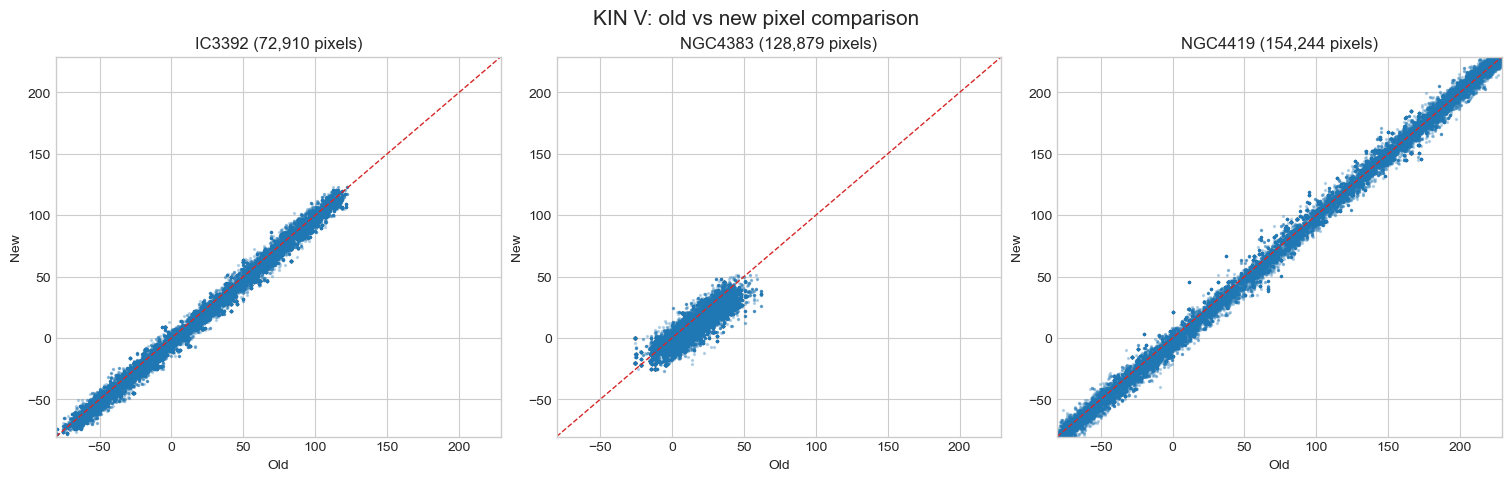

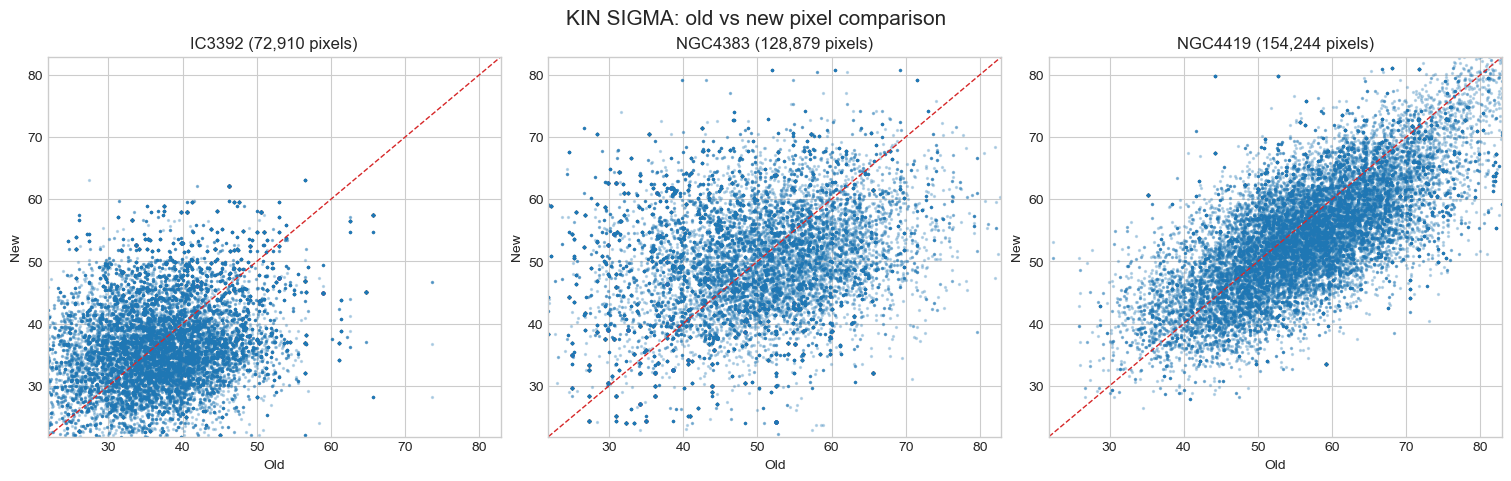

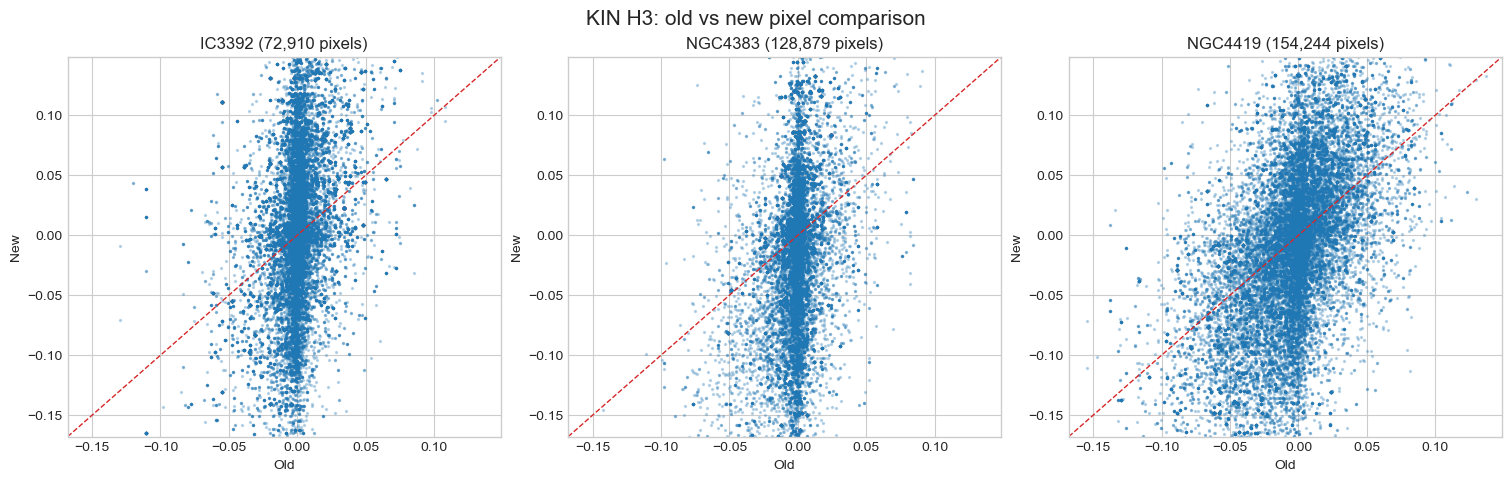

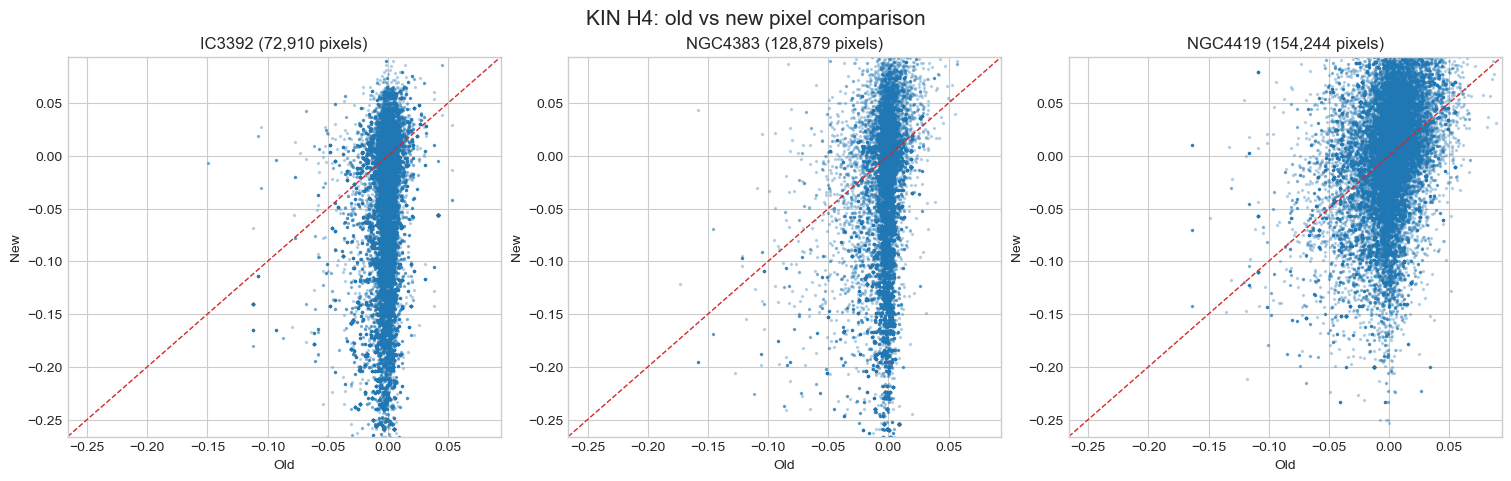

In [6]:
def scatter_kin(quantity, max_points=30000, random_state=1):
    rng = np.random.default_rng(random_state)
    galaxy_values = {}
    all_old_new = []

    for galaxy in GALAXIES:
        old_map, new_map = maps[galaxy][quantity]
        mask = np.isfinite(old_map) & np.isfinite(new_map)
        old_vals = old_map[mask]
        new_vals = new_map[mask]
        galaxy_values[galaxy] = (old_vals, new_vals)
        all_old_new.extend([old_vals, new_vals])

    all_values = finite_values(all_old_new)
    lo, hi = robust_limits(all_values, p=(1, 99))

    fig, axes = plt.subplots(
        1,
        len(GALAXIES),
        figsize=(5.0 * len(GALAXIES), 4.7),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(f'KIN {quantity}: old vs new pixel comparison', fontsize=15)

    for col, galaxy in enumerate(GALAXIES):
        ax = axes[0, col]
        old_vals, new_vals = galaxy_values[galaxy]
        n_points = old_vals.size
        if n_points == 0:
            ax.set_title(f'{galaxy}: no valid overlap')
            continue
        if n_points > max_points:
            idx = rng.choice(n_points, size=max_points, replace=False)
            plot_old = old_vals[idx]
            plot_new = new_vals[idx]
        else:
            plot_old = old_vals
            plot_new = new_vals

        ax.scatter(plot_old, plot_new, s=2, alpha=0.25)
        ax.plot([lo, hi], [lo, hi], color='tab:red', linestyle='--', linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Old')
        ax.set_ylabel('New')
        ax.set_title(f'{galaxy} ({n_points:,} pixels)')

    plt.show()


for quantity in KIN_QUANTITIES:
    scatter_kin(quantity)


## Focused V and SIGMA residual diagnostics

This cell isolates the two KIN quantities that need the most careful visual judgement. The old-vs-new scatter checks whether the maps follow the 1:1 relation. The residual panels show whether the points are systematically offset from zero.


,galaxy,quantity,pearson_r,median_delta_new_minus_old,median_abs_delta,p16_delta,p84_delta,rms_delta,median_abs_pct_change
0,IC3392,KIN_V,0.994838,-2.951950,4.002496,-7.953875,2.128128,6.047531,9.535885
1,IC3392,KIN_SIGMA,0.313510,-0.279706,6.734966,-9.442828,10.064723,10.011904,17.538488
2,NGC4383,KIN_V,0.388881,-5.749124,6.522286,-13.128430,1.151179,38.508259,43.550366
3,NGC4383,KIN_SIGMA,0.110906,1.081543,9.094896,-10.753085,16.979188,29.087724,19.310408
4,NGC4419,KIN_V,0.997993,-1.086678,3.888859,-6.585770,4.740147,6.323867,4.590756
5,NGC4419,KIN_SIGMA,0.751359,-1.917980,5.232351,-9.618811,5.427795,8.271481,9.371364


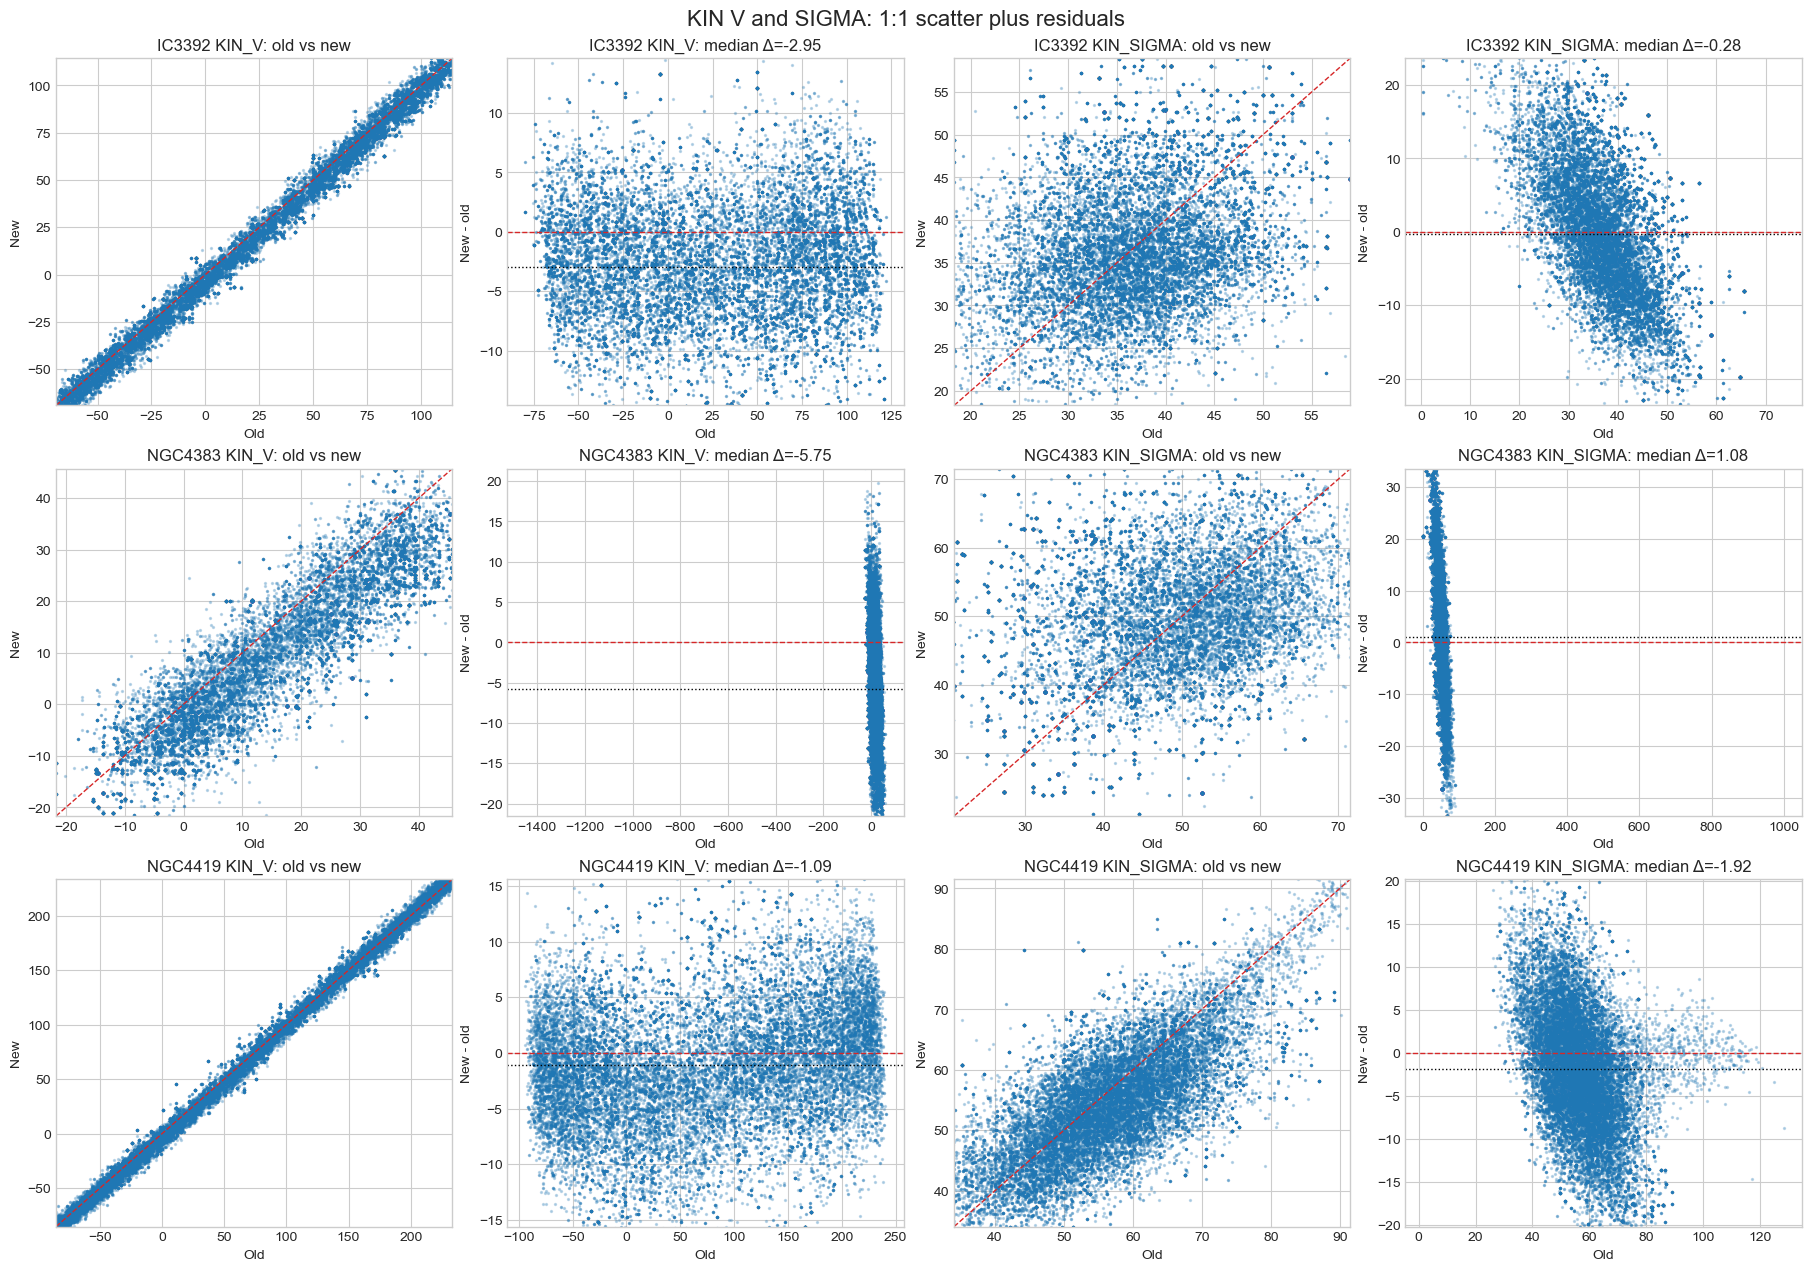

In [7]:
def velocity_sigma_offset_summary():
    rows = []
    for galaxy in GALAXIES:
        for quantity in ['V', 'SIGMA']:
            old_map, new_map = maps[galaxy][quantity]
            old_map, new_map = align_map_pair(old_map, new_map, f'{galaxy} KIN_{quantity}')
            mask = np.isfinite(old_map) & np.isfinite(new_map)
            row = compare_stats(old_map, new_map, f'KIN_{quantity}', galaxy)
            if mask.sum() == 0:
                row.update(
                    {
                        'median_abs_delta': np.nan,
                        'p16_delta': np.nan,
                        'p84_delta': np.nan,
                    }
                )
            else:
                delta = new_map[mask] - old_map[mask]
                row.update(
                    {
                        'median_abs_delta': float(np.nanmedian(np.abs(delta))),
                        'p16_delta': float(np.nanpercentile(delta, 16)),
                        'p84_delta': float(np.nanpercentile(delta, 84)),
                    }
                )
            rows.append(row)

    columns = [
        'galaxy',
        'quantity',
        'pearson_r',
        'median_delta_new_minus_old',
        'median_abs_delta',
        'p16_delta',
        'p84_delta',
        'rms_delta',
        'median_abs_pct_change',
    ]
    return pd.DataFrame(rows)[columns]


velocity_sigma_focus = velocity_sigma_offset_summary()
display(velocity_sigma_focus)


def plot_velocity_sigma_residuals(max_points=30000, random_state=2):
    rng = np.random.default_rng(random_state)
    fig, axes = plt.subplots(
        len(GALAXIES),
        4,
        figsize=(18, 4.2 * len(GALAXIES)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('KIN V and SIGMA: 1:1 scatter plus residuals', fontsize=16)

    for row, galaxy in enumerate(GALAXIES):
        for q_index, quantity in enumerate(['V', 'SIGMA']):
            old_map, new_map = maps[galaxy][quantity]
            mask = np.isfinite(old_map) & np.isfinite(new_map)
            old_vals = old_map[mask]
            new_vals = new_map[mask]
            delta = new_vals - old_vals

            if old_vals.size == 0:
                for col_offset in (0, 1):
                    axes[row, 2 * q_index + col_offset].set_title(f'{galaxy} KIN_{quantity}: no valid overlap')
                continue

            if old_vals.size > max_points:
                idx = rng.choice(old_vals.size, size=max_points, replace=False)
                plot_old = old_vals[idx]
                plot_new = new_vals[idx]
                plot_delta = delta[idx]
            else:
                plot_old = old_vals
                plot_new = new_vals
                plot_delta = delta

            scatter_ax = axes[row, 2 * q_index]
            residual_ax = axes[row, 2 * q_index + 1]

            lim_lo, lim_hi = robust_limits(np.r_[old_vals, new_vals], p=(1, 99))
            scatter_ax.scatter(plot_old, plot_new, s=2, alpha=0.25)
            scatter_ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color='tab:red', linestyle='--', linewidth=1)
            scatter_ax.set_xlim(lim_lo, lim_hi)
            scatter_ax.set_ylim(lim_lo, lim_hi)
            scatter_ax.set_xlabel('Old')
            scatter_ax.set_ylabel('New')
            scatter_ax.set_title(f'{galaxy} KIN_{quantity}: old vs new')

            dlim = robust_symmetric_limit(delta, percentile=98, fallback=1.0)
            median_delta = np.nanmedian(delta)
            residual_ax.scatter(plot_old, plot_delta, s=2, alpha=0.25)
            residual_ax.axhline(0.0, color='tab:red', linestyle='--', linewidth=1)
            residual_ax.axhline(median_delta, color='black', linestyle=':', linewidth=1)
            residual_ax.set_ylim(-dlim, dlim)
            residual_ax.set_xlabel('Old')
            residual_ax.set_ylabel('New - old')
            residual_ax.set_title(f'{galaxy} KIN_{quantity}: median Δ={median_delta:.2f}')

    plt.show()


plot_velocity_sigma_residuals()


## Interpreting the KIN differences

The KIN differences here should be read as a combined effect of the new input cube, the new CONFIG, and the newer `nGIST`/pPXF workflow. The cube update is expected to be the smallest term. The largest term is probably the CONFIG change, especially because the KIN fit is no longer the same fit: the old run fits `4800-7000`, while the new run fits `4800-9100`. The `nGIST` version change then matters because v7.6.8 uses a different internal fitting workflow: dust handling, optimal-template selection, variance/noise weighting, and clipping are all different enough that the same spectrum is not weighted and masked in exactly the old way.

For `V`, the IC3392 and NGC4419 scatter plots mostly follow the 1:1 line, but the focused residual table shows a small negative median shift (`new - old` is about `-3 km/s` for IC3392 and about `-1 km/s` for NGC4419). That is best interpreted as a velocity zero-point-like offset, not a random map failure. In pPXF, velocity is the global wavelength shift that best aligns the stellar absorption pattern. If the fit now gives extra weight to different parts of the spectrum, the optimum shift can move slightly even when the large-scale velocity field is preserved. The likely causes are the wider fitting window, the changed template set (`MILES_EMLINES` to `EMILES_baseFe_EMLINES`), the changed LSF description (`lsf_MUSE-WFM` to `lsf_MUSE-WFM-MILES`), the changed velocity scale (`53` to `41`), the new variance weighting, and the narrower sky/emission masking. The red part of the spectrum adds features and systematics that were absent from the old `4800-7000` fit, especially around the Ca triplet and sky-contaminated regions, so the blue-only and full-range fits do not have to choose exactly the same velocity. This is why a cloud can be almost parallel to the 1:1 line but slightly displaced from it.

NGC4383 is different: its `V` comparison does not just look like a constant offset. The low correlation and large RMS residual mean that the velocity residual is spatially structured. That points to a change in the fitted solution in some regions, not merely a uniform velocity zero point. The same causes still apply, but in this case the extended wavelength range, changed masks, changed variance weighting, and changed template/LSF matching appear to alter which absorption features dominate the fit in different parts of the cube. So for NGC4383 I would not call the velocity map stable without checking the residual map and the spectra in the affected regions.

For `SIGMA`, the deviation is expected to be stronger than for `V`. Velocity is mostly a shift; sigma is a line-broadening parameter. Sigma is therefore much more sensitive to template mismatch, wavelength-dependent LSF matching, continuum treatment, and bad-pixel rejection. Extending the fit from `7000` to `9100` means pPXF must find one stellar velocity dispersion that works for both the blue optical absorption features and the redder features. If the red region has different LSF uncertainty, different sky residuals, different masking, or different template mismatch, the best-fit broadening changes. The CONFIG also changes `SIGMA` initial value (`66` to `82`), `ADEG` (`12` to `23`), template library, spectral mask, and noise handling. Those changes can broaden the scatter around the 1:1 line even if the median sigma is similar. In this notebook that is exactly the pattern: the median sigma offsets are not huge for every galaxy, but the scatter and correlation show clear deviation.

For `H3` and `H4`, the maps are not expected to be comparable one-to-one. These moments describe asymmetric and kurtotic deviations from a Gaussian line-of-sight velocity distribution. They are estimated from subtle line-profile residuals, so they are the first quantities to react when masking, templates, continuum shape, LSF, or noise weighting changes. On top of that, the BIAS setting changed from the old `Auto` setting to the new `muse_snr_prefit` setting. The pPXF bias is not a cosmetic parameter: it directly regularizes high-order moments toward zero when the data do not strongly justify them. A different, S/N-aware or prefit-calibrated bias changes the balance between “fit this residual with H3/H4” and “treat this residual as noise/template mismatch and keep the LOSVD closer to Gaussian.” That is why `H3` and `H4` can change dramatically even when `V` still broadly follows the old velocity field.

So the safest causal summary is:

- `V`: mostly robust in IC3392 and NGC4419, but with a real offset caused by changed spectral weighting/masking/template/LSF setup; NGC4383 shows spatially varying changes, not just an offset.
- `SIGMA`: clear deviation, most likely driven by the new full `4800-9100` fit plus LSF/template/continuum/noise/masking changes; nGIST v7.6.8 contributes because it changes how those ingredients enter pPXF.
- `H3/H4`: expected to change; the changed bias prescription is a primary reason, and the wider wavelength range plus new template/mask/noise/clipping choices amplify it.

A strict attribution would require controlled reruns: same cube and same CONFIG in both nGIST versions, then same cube with only the wavelength range changed, then same cube/config with only the template and mask changes. Without those controlled runs, this notebook should say “CONFIG plus nGIST workflow”, with the `4800-9100` KIN range as the dominant practical difference.


## Summary statistics

The table below is the compact cross-galaxy result. Use it together with the visual cells above: `pearson_r` captures whether the point cloud follows the same trend, while `median_delta_new_minus_old`, `rms_delta`, and `median_abs_pct_change` show offsets and scatter around that trend.

For `H3` and `H4`, percent changes are not physically helpful near zero, so the absolute deltas and the maps are more informative.


In [8]:
summary_rows = []
for galaxy in GALAXIES:
    for quantity in KIN_QUANTITIES:
        old_map, new_map = maps[galaxy][quantity]
        summary_rows.append(compare_stats(old_map, new_map, f'KIN_{quantity}', galaxy))

summary = pd.DataFrame(summary_rows)
summary = summary[
    [
        'galaxy',
        'quantity',
        'n_valid',
        'n_valid_nonzero_old',
        'median_old',
        'median_new',
        'median_delta_new_minus_old',
        'mean_delta_new_minus_old',
        'std_delta',
        'rms_delta',
        'median_pct_change',
        'median_abs_pct_change',
        'mean_pct_change',
        'std_pct_change',
        'rms_pct_change',
        'pearson_r',
    ]
]

display(summary)

summary_pivot = summary.pivot(
    index='quantity',
    columns='galaxy',
    values=['pearson_r', 'rms_delta', 'median_abs_pct_change'],
)
display(summary_pivot)


,galaxy,quantity,n_valid,n_valid_nonzero_old,median_old,median_new,median_delta_new_minus_old,mean_delta_new_minus_old,std_delta,rms_delta,median_pct_change,median_abs_pct_change,mean_pct_change,std_pct_change,rms_pct_change,pearson_r
0,IC3392,KIN_V,72910,72910,26.748543,22.354665,-2.951950,-2.951923,5.278141,6.047531,-6.048504,9.535885,-26.311100,304.303566,305.438921,0.994838
1,IC3392,KIN_SIGMA,72910,72910,37.771248,37.191840,-0.279706,0.362265,10.005348,10.011904,-0.827553,17.538488,20.204034,305.037488,305.705859,0.313510
2,IC3392,KIN_H3,72910,72910,-0.000109,0.008194,0.009685,0.013858,0.069111,0.070487,113.667127,568.662692,-1688.279174,195577.102665,195584.389391,0.361043
3,IC3392,KIN_H4,72910,72910,-0.000955,-0.049443,-0.046083,-0.069346,0.086913,0.111187,-883.523919,1134.190641,-5499.921690,35382.546917,35807.454041,0.168361
4,NGC4383,KIN_V,128879,128520,12.211599,7.326136,-5.749124,-4.909618,38.194000,38.508259,-36.332493,43.550366,-356.140450,3778.232982,3794.980960,0.388881
5,NGC4383,KIN_SIGMA,128879,128879,46.601409,48.614799,1.081543,1.846580,29.029051,29.087724,2.164697,19.310408,25.570567,268.595406,269.809833,0.110906
6,NGC4383,KIN_H3,128879,128520,-0.000760,-0.004297,-0.004199,-0.013292,0.063504,0.064880,-61.980562,747.569948,-706.814305,50540.259385,50545.201604,0.311088
7,NGC4383,KIN_H4,128879,128520,-0.000480,-0.017411,-0.015959,-0.047083,0.082822,0.095270,-530.604807,998.422744,-5323.853901,205385.213059,205454.202108,0.171498
8,NGC4419,KIN_V,154244,154243,75.192382,72.768711,-1.086678,-0.961420,6.250357,6.323867,-1.118921,4.590756,-24.550989,2033.479999,2033.628201,0.997993
9,NGC4419,KIN_SIGMA,154244,154244,56.980355,54.985583,-1.917980,-2.091276,8.002747,8.271481,-3.396997,9.371364,-2.132491,28.494586,28.574270,0.751359


pearson_r                      rms_delta                       \
galaxy       IC3392   NGC4383   NGC4419     IC3392    NGC4383   NGC4419   
quantity                                                                  
KIN_H3     0.361043  0.311088  0.548957   0.070487   0.064880  0.066325   
KIN_H4     0.168361  0.171498  0.331688   0.111187   0.095270  0.055868   
KIN_SIGMA  0.313510  0.110906  0.751359  10.011904  29.087724  8.271481   
KIN_V      0.994838  0.388881  0.997993   6.047531  38.508259  6.323867   

          median_abs_pct_change                          
galaxy                   IC3392     NGC4383     NGC4419  
quantity                                                 
KIN_H3               568.662692  747.569948  211.723202  
KIN_H4              1134.190641  998.422744  331.476215  
KIN_SIGMA             17.538488   19.310408    9.371364  
KIN_V                  9.535885   43.550366    4.590756

## Automatic interpretation helper

This is a conservative helper, not a replacement for visual inspection. It separates the cases we care about:

- `V`: can be strongly correlated but still offset from 1:1,
- `SIGMA`: treated as a clear deviation when correlation is weak or scatter is large,
- `H3` and `H4`: marked as known changed / not judged as stability tests.


In [9]:
PEARSON_SIMILAR_LIMIT = 0.90
VELOCITY_MEDIAN_OFFSET_LIMIT = 1.0
VELOCITY_PCT_SIMILAR_LIMIT = 5.0
SIGMA_PEARSON_CLEAR_LIMIT = 0.90
SIGMA_PCT_CLEAR_LIMIT = 10.0


def kin_family(quantity):
    name = quantity.replace('KIN_', '', 1)
    if name == 'V':
        return 'kin_velocity'
    if name == 'SIGMA':
        return 'kin_sigma'
    if name in {'H3', 'H4'}:
        return 'kin_moment'
    return 'kin'


def format_metric_value(value):
    if not np.isfinite(value):
        return 'nan'
    if value == 0:
        return '0'
    if abs(value) >= 1000 or abs(value) < 0.001:
        return f'{value:.3e}'
    return f'{value:.3g}'


def classify_kin_row(row):
    quantity = row['quantity']
    family = row['family']

    if row['n_valid'] == 0:
        return 'no valid overlap', 'No pixels are finite in both runs.'

    pearson_r = row['pearson_r']
    median_delta = row['median_delta_new_minus_old']
    median_abs_pct = row['median_abs_pct_change']
    rms_delta = row['rms_delta']

    if family == 'kin_moment':
        return (
            'known changed / not judged',
            'Higher moments are expected to change; use maps and absolute deltas, not percent differences.',
        )

    if family == 'kin_velocity':
        if not np.isfinite(pearson_r) or pearson_r < PEARSON_SIMILAR_LIMIT:
            return (
                'velocity changes a lot',
                f'pearson_r={format_metric_value(pearson_r)}; median_delta={format_metric_value(median_delta)}',
            )
        if (
            abs(median_delta) > VELOCITY_MEDIAN_OFFSET_LIMIT
            or (
                np.isfinite(median_abs_pct)
                and median_abs_pct > VELOCITY_PCT_SIMILAR_LIMIT
            )
        ):
            return (
                'velocity correlated but offset',
                'pearson_r='
                f'{format_metric_value(pearson_r)}; median_delta={format_metric_value(median_delta)}; '
                f'median_abs_pct={format_metric_value(median_abs_pct)}%',
            )
        return (
            'velocity similar',
            'pearson_r='
            f'{format_metric_value(pearson_r)}; median_delta={format_metric_value(median_delta)}; '
            f'median_abs_pct={format_metric_value(median_abs_pct)}%',
        )

    if family == 'kin_sigma':
        if (
            not np.isfinite(pearson_r)
            or pearson_r < SIGMA_PEARSON_CLEAR_LIMIT
            or (
                np.isfinite(median_abs_pct)
                and median_abs_pct > SIGMA_PCT_CLEAR_LIMIT
            )
        ):
            return (
                'sigma clear deviation',
                'pearson_r='
                f'{format_metric_value(pearson_r)}; rms_delta={format_metric_value(rms_delta)}; '
                f'median_abs_pct={format_metric_value(median_abs_pct)}%',
            )
        return (
            'sigma broadly similar',
            'pearson_r='
            f'{format_metric_value(pearson_r)}; rms_delta={format_metric_value(rms_delta)}; '
            f'median_abs_pct={format_metric_value(median_abs_pct)}%',
        )

    return 'not classified', f'{quantity} was not assigned a KIN family.'


auto_conclusion = summary.copy()
auto_conclusion['family'] = auto_conclusion['quantity'].map(kin_family)
classified = auto_conclusion.apply(classify_kin_row, axis=1, result_type='expand')
auto_conclusion['auto_conclusion'] = classified[0]
auto_conclusion['decision_metrics'] = classified[1]
auto_conclusion = auto_conclusion[
    [
        'galaxy',
        'quantity',
        'family',
        'auto_conclusion',
        'decision_metrics',
        'pearson_r',
        'median_delta_new_minus_old',
        'median_abs_pct_change',
        'rms_delta',
    ]
]

display(auto_conclusion)

for galaxy in GALAXIES:
    rows = auto_conclusion[auto_conclusion['galaxy'] == galaxy]
    print(f'\n{galaxy}')
    for label in [
        'velocity similar',
        'velocity correlated but offset',
        'velocity changes a lot',
        'sigma broadly similar',
        'sigma clear deviation',
        'known changed / not judged',
        'no valid overlap',
    ]:
        quantities = rows.loc[rows['auto_conclusion'] == label, 'quantity'].tolist()
        print(f'  {label}: {quantities if quantities else "None"}')


,galaxy,quantity,family,auto_conclusion,decision_metrics,pearson_r,median_delta_new_minus_old,median_abs_pct_change,rms_delta
0,IC3392,KIN_V,kin_velocity,velocity correlated but offset,pearson_r=0.995; median_delta=-2.95; median_ab...,0.994838,-2.951950,9.535885,6.047531
1,IC3392,KIN_SIGMA,kin_sigma,sigma clear deviation,pearson_r=0.314; rms_delta=10; median_abs_pct=...,0.313510,-0.279706,17.538488,10.011904
2,IC3392,KIN_H3,kin_moment,known changed / not judged,Higher moments are expected to change; use map...,0.361043,0.009685,568.662692,0.070487
3,IC3392,KIN_H4,kin_moment,known changed / not judged,Higher moments are expected to change; use map...,0.168361,-0.046083,1134.190641,0.111187
4,NGC4383,KIN_V,kin_velocity,velocity changes a lot,pearson_r=0.389; median_delta=-5.75,0.388881,-5.749124,43.550366,38.508259
5,NGC4383,KIN_SIGMA,kin_sigma,sigma clear deviation,pearson_r=0.111; rms_delta=29.1; median_abs_pc...,0.110906,1.081543,19.310408,29.087724
6,NGC4383,KIN_H3,kin_moment,known changed / not judged,Higher moments are expected to change; use map...,0.311088,-0.004199,747.569948,0.064880
7,NGC4383,KIN_H4,kin_moment,known changed / not judged,Higher moments are expected to change; use map...,0.171498,-0.015959,998.422744,0.095270
8,NGC4419,KIN_V,kin_velocity,velocity correlated but offset,pearson_r=0.998; median_delta=-1.09; median_ab...,0.997993,-1.086678,4.590756,6.323867
9,NGC4419,KIN_SIGMA,kin_sigma,sigma clear deviation,pearson_r=0.751; rms_delta=8.27; median_abs_pc...,0.751359,-1.917980,9.371364,8.271481



IC3392
  velocity similar: None
  velocity correlated but offset: ['KIN_V']
  velocity changes a lot: None
  sigma broadly similar: None
  sigma clear deviation: ['KIN_SIGMA']
  known changed / not judged: ['KIN_H3', 'KIN_H4']
  no valid overlap: None

NGC4383
  velocity similar: None
  velocity correlated but offset: None
  velocity changes a lot: ['KIN_V']
  sigma broadly similar: None
  sigma clear deviation: ['KIN_SIGMA']
  known changed / not judged: ['KIN_H3', 'KIN_H4']
  no valid overlap: None

NGC4419
  velocity similar: None
  velocity correlated but offset: ['KIN_V']
  velocity changes a lot: None
  sigma broadly similar: None
  sigma clear deviation: ['KIN_SIGMA']
  known changed / not judged: ['KIN_H3', 'KIN_H4']
  no valid overlap: None


## Optional save

Uncomment the lines below if you want CSV versions of the summary tables for a report or paper note.


In [10]:
# summary.to_csv('KIN_3galaxies_v3_vs_v3tk_summary_stats.csv', index=False)
# auto_conclusion.to_csv('KIN_3galaxies_v3_vs_v3tk_auto_conclusion.csv', index=False)
# print('Saved KIN comparison CSV files.')
